# SENTINELA · D8 — Statistical Computing with R & Python
**Global Solution 2026.1 · FIAP · Indústria Espacial**  
**Dupla:** Rafael & Charles  
**Objetivo:** Coleta, organização e análise estatística de dados climáticos do Rio Grande do Sul  
**Dataset:** INMET — Estações automáticas do RS (2014–2025, 12 anos)  
**Cidades:** Porto Alegre, Santa Maria, Passo Fundo, Bento Gonçalves, Teutônia  
**Conexão SENTINELA:** Este dataset é o mesmo utilizado nos modelos de ML (D5) e Rede Neural (D7)

## 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de estilo
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento e limpeza dos dados do INMET

### 2.1 Upload dos arquivos anuais
Baixe de [portal.inmet.gov.br/dadoshistoricos](https://portal.inmet.gov.br/dadoshistoricos) um arquivo ZIP por ano, de **2014 a 2025**. Faça upload de todos de uma vez na célula abaixo (use Ctrl+clique para selecionar múltiplos). O código localiza automaticamente as 5 estações do RS pelo código WMO em cada ano.

In [3]:
from google.colab import files
import os

# ─── UPLOAD DOS ZIPs ANUAIS DO INMET (2014 a 2025) ───────────────────────────
# Baixe de https://portal.inmet.gov.br/dadoshistoricos um ZIP por ano.
# Faça upload de todos de uma vez (Ctrl+clique para selecionar vários).
print("Selecione os arquivos ZIP anuais do INMET (2014.zip ate 2025.zip)...")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'Arquivo "{fn}" ({len(uploaded[fn])/1024/1024:.1f} MB) carregado')

print("\nArquivos no ambiente:", [a for a in os.listdir('.') if a.endswith('.zip')])


Selecione os arquivos ZIP anuais do INMET (2014.zip ate 2025.zip)...


Saving 2014.zip to 2014.zip
Saving 2015.zip to 2015.zip
Saving 2016.zip to 2016.zip
Saving 2017.zip to 2017.zip
Saving 2018.zip to 2018.zip
Saving 2019.zip to 2019.zip
Saving 2020.zip to 2020.zip
Saving 2021.zip to 2021.zip
Saving 2022.zip to 2022.zip
Saving 2023.zip to 2023.zip
Saving 2024.zip to 2024.zip
Saving 2025.zip to 2025.zip
Arquivo "2014.zip" (94.3 MB) carregado
Arquivo "2015.zip" (93.4 MB) carregado
Arquivo "2016.zip" (97.7 MB) carregado
Arquivo "2017.zip" (104.6 MB) carregado
Arquivo "2018.zip" (112.4 MB) carregado
Arquivo "2019.zip" (112.1 MB) carregado
Arquivo "2020.zip" (98.9 MB) carregado
Arquivo "2021.zip" (76.8 MB) carregado
Arquivo "2022.zip" (86.2 MB) carregado
Arquivo "2023.zip" (102.1 MB) carregado
Arquivo "2024.zip" (98.0 MB) carregado
Arquivo "2025.zip" (86.7 MB) carregado

Arquivos no ambiente: ['2017.zip', '2025.zip', '2022.zip', '2019.zip', '2016.zip', '2021.zip', '2014.zip', '2020.zip', '2024.zip', '2015.zip', '2018.zip', '2023.zip']


Agora que os arquivos foram carregados para o ambiente do Colab, você pode executar a célula abaixo (que você já possui) para processar o dataframe `df`.

In [4]:
import zipfile
import os
import glob
import pandas as pd
import numpy as np

# ─── DESCOMPACTAR TODOS OS ZIPs ANUAIS ───────────────────────────────────────
anos = range(2014, 2026)  # 2014 ate 2025 (12 anos)
for ano in anos:
    zip_nome = f'{ano}.zip'
    if os.path.exists(zip_nome):
        with zipfile.ZipFile(zip_nome, 'r') as zip_ref:
            zip_ref.extractall(f'{ano}')
        print(f'✓ {zip_nome} descompactado')

# ─── CIDADES-ALVO (código WMO da estação) ────────────────────────────────────
# Usamos o código WMO porque o nome do arquivo varia de ano para ano.
cidades_wmo = {
    'Porto Alegre'   : 'A801',
    'Santa Maria'    : 'A803',
    'Passo Fundo'    : 'A839',
    'Bento Gonçalves': 'A840',
    'Teutônia'       : 'A882',
}

COLUNAS = [
    'data', 'hora_utc', 'precipitacao_mm', 'pressao_hpa',
    'pressao_max_hpa', 'pressao_min_hpa', 'radiacao_kj',
    'temperatura_c', 'temp_orvalho_c', 'temp_max_c', 'temp_min_c',
    'orvalho_max_c', 'orvalho_min_c', 'umidade_max_pct',
    'umidade_min_pct', 'umidade_pct', 'vento_dir_gr',
    'vento_rajada_ms', 'vento_vel_ms'
]

def localizar_arquivos(wmo):
    """Procura todos os CSVs de uma estação (por código WMO) em todas as pastas de ano."""
    padrao = f'**/INMET_S_RS_{wmo}_*.CSV'
    encontrados = glob.glob(padrao, recursive=True)
    # Alguns anos vêm com extensão minúscula
    encontrados += glob.glob(f'**/INMET_S_RS_{wmo}_*.csv', recursive=True)
    return sorted(set(encontrados))

def carregar_csv(caminho, cidade):
    """Carrega e limpa UM CSV anual do INMET, retornando DataFrame diário."""
    try:
        df = pd.read_csv(caminho, sep=';', encoding='latin-1',
                         skiprows=8, decimal=',',
                         na_values=['-9999', '-9999.0', '', ' '])
        df = df.iloc[:, :len(COLUNAS)]
        df.columns = COLUNAS

        df['data'] = pd.to_datetime(df['data'], format='%Y/%m/%d', errors='coerce')
        # Alguns anos usam formato YYYY-MM-DD
        mask_na = df['data'].isna()
        if mask_na.any():
            df.loc[mask_na, 'data'] = pd.to_datetime(
                df.loc[mask_na, 'data'], errors='coerce')
        df = df.dropna(subset=['data'])

        for col in ['precipitacao_mm','temperatura_c','temp_max_c','temp_min_c',
                    'umidade_pct','pressao_hpa','vento_rajada_ms']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Filtros físicos de sanidade
        df.loc[df['temperatura_c'].abs() > 60, 'temperatura_c'] = np.nan
        df.loc[(df['umidade_pct'] > 100) | (df['umidade_pct'] < 0), 'umidade_pct'] = np.nan
        df.loc[df['precipitacao_mm'] < 0, 'precipitacao_mm'] = np.nan

        diario = df.groupby('data').agg(
            precipitacao_mm=('precipitacao_mm', 'sum'),
            temperatura_media_c=('temperatura_c', 'mean'),
            temperatura_max_c=('temp_max_c', 'max'),
            temperatura_min_c=('temp_min_c', 'min'),
            umidade_media_pct=('umidade_pct', 'mean'),
            pressao_media_hpa=('pressao_hpa', 'mean'),
            vento_max_ms=('vento_rajada_ms', 'max'),
        ).reset_index()
        diario['cidade'] = cidade
        return diario
    except Exception as e:
        print(f'   ⚠ erro em {os.path.basename(caminho)}: {e}')
        return pd.DataFrame()

# ─── CARREGA TODOS OS ANOS DE TODAS AS CIDADES ───────────────────────────────
dfs = []
print('\nCarregando series historicas 2014-2025...\n')
for cidade, wmo in cidades_wmo.items():
    arquivos_cidade = localizar_arquivos(wmo)
    if not arquivos_cidade:
        print(f'✗ {cidade:18s} ({wmo}): nenhum arquivo encontrado')
        continue
    partes = [carregar_csv(arq, cidade) for arq in arquivos_cidade]
    partes = [p for p in partes if not p.empty]
    if partes:
        df_cidade = pd.concat(partes, ignore_index=True).drop_duplicates('data')
        dfs.append(df_cidade)
        anos_cob = f"{df_cidade['data'].dt.year.min()}-{df_cidade['data'].dt.year.max()}"
        print(f'✓ {cidade:18s} ({wmo}): {len(df_cidade):5d} dias | {len(arquivos_cidade):2d} anos | {anos_cob}')

# ─── CONSOLIDA ────────────────────────────────────────────────────────────────
df = pd.concat(dfs, ignore_index=True)
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year
df['evento_extremo'] = (df['precipitacao_mm'] >= 30).astype(int)

print(f'\n{"="*60}')
print(f'Total geral: {len(df):,} registros diarios')
print(f'Periodo: {df["data"].min().date()} a {df["data"].max().date()}')
print(f'Cidades: {df["cidade"].nunique()} | Anos: {df["ano"].nunique()}')
print(f'Eventos extremos (>=30mm): {df["evento_extremo"].sum():,} dias ({df["evento_extremo"].mean()*100:.1f}%)')
print(f'{"="*60}')
df.head()


✓ 2014.zip descompactado
✓ 2015.zip descompactado
✓ 2016.zip descompactado
✓ 2017.zip descompactado
✓ 2018.zip descompactado
✓ 2019.zip descompactado
✓ 2020.zip descompactado
✓ 2021.zip descompactado
✓ 2022.zip descompactado
✓ 2023.zip descompactado
✓ 2024.zip descompactado
✓ 2025.zip descompactado

Carregando series historicas 2014-2025...

✓ Porto Alegre       (A801):  2557 dias | 12 anos | 2019-2025
✓ Santa Maria        (A803):  2557 dias | 12 anos | 2019-2025
✓ Passo Fundo        (A839):  2557 dias | 12 anos | 2019-2025
✓ Bento Gonçalves    (A840):  2557 dias | 12 anos | 2019-2025
✓ Teutônia           (A882):  2557 dias | 12 anos | 2019-2025

Total geral: 12,785 registros diarios
Periodo: 2019-01-01 a 2025-12-31
Cidades: 5 | Anos: 7
Eventos extremos (>=30mm): 510 dias (4.0%)


,data,precipitacao_mm,temperatura_media_c,temperatura_max_c,temperatura_min_c,umidade_media_pct,pressao_media_hpa,vento_max_ms,cidade,mes,ano,evento_extremo
0,2019-01-01,0.0,28.733333,36.4,23.3,72.916667,1006.220833,9.5,Porto Alegre,1,2019,0
1,2019-01-02,0.0,30.533333,38.5,24.3,66.666667,1003.462500,9.6,Porto Alegre,1,2019,0
2,2019-01-03,11.0,26.925000,34.1,21.1,83.625000,1001.237500,8.5,Porto Alegre,1,2019,0
3,2019-01-04,3.0,21.950000,26.0,19.6,88.541667,1007.608333,7.5,Porto Alegre,1,2019,0
4,2019-01-05,0.0,23.091667,28.4,20.1,78.291667,1008.583333,9.4,Porto Alegre,1,2019,0


## 3. Tabela de Distribuição de Frequências — Precipitação Diária

In [5]:
# ─── FAIXAS DE PRECIPITAÇÃO ───────────────────────────────────────────────────
# Thresholds baseados em critérios meteorológicos do INMET e OMM:
#   0–5mm   → sem chuva significativa
#   5–15mm  → chuva fraca a moderada
#   15–30mm → chuva moderada a forte
#   30–60mm → evento intenso (threshold de alerta)
#   >60mm   → evento extremo (risco de enchente)

bins   = [0, 5, 15, 30, 60, float('inf')]
labels = ['0–5 mm (sem signif.)', '5–15 mm (fraca/mod.)',
          '15–30 mm (mod./forte)', '30–60 mm (intensa)', '>60 mm (extrema)']

precip_todos = df['precipitacao_mm'].dropna()
precip_todos = precip_todos[precip_todos > 0]  # apenas dias com chuva

freq_abs  = pd.cut(precip_todos, bins=bins, labels=labels, right=False).value_counts().sort_index()
freq_rel  = (freq_abs / freq_abs.sum() * 100).round(2)
freq_acum = freq_rel.cumsum().round(2)

tabela_freq = pd.DataFrame({
    'Faixa de Precipitação'  : labels,
    'Freq. Absoluta (dias)'  : freq_abs.values,
    'Freq. Relativa (%)'     : freq_rel.values,
    'Freq. Acumulada (%)'    : freq_acum.values,
})

print('=' * 70)
print('TABELA DE DISTRIBUIÇÃO DE FREQUÊNCIAS — PRECIPITAÇÃO DIÁRIA')
print('Dados: 5 estações do RS · 2014–2025 · Apenas dias com precipitação > 0mm')
print('=' * 70)
print(tabela_freq.to_string(index=False))
print('=' * 70)
print(f'Total de dias com chuva: {freq_abs.sum()}')
print(f'Dias com evento extremo (≥30mm): {freq_abs.iloc[3:].sum()} '
      f'({freq_rel.iloc[3:].sum():.1f}% dos dias chuvosos)')

TABELA DE DISTRIBUIÇÃO DE FREQUÊNCIAS — PRECIPITAÇÃO DIÁRIA
Dados: 5 estações do RS · 2014–2025 · Apenas dias com precipitação > 0mm
Faixa de Precipitação  Freq. Absoluta (dias)  Freq. Relativa (%)  Freq. Acumulada (%)
 0–5 mm (sem signif.)                   2764               55.09                55.09
 5–15 mm (fraca/mod.)                   1096               21.85                76.94
15–30 mm (mod./forte)                    647               12.90                89.84
   30–60 mm (intensa)                    385                7.67                97.51
     >60 mm (extrema)                    125                2.49               100.00
Total de dias com chuva: 5017
Dias com evento extremo (≥30mm): 510 (10.2% dos dias chuvosos)


**Interpretação:** A tabela revela que a grande maioria dos dias com precipitação no RS concentra-se nas faixas de baixa intensidade (0–15mm). Porém, os eventos acima de 30mm — considerados intensos pelo INMET — representam uma parcela que, embora minoritária em dias, é responsável pelo maior volume acumulado e pelos maiores riscos de enchente. Esta distribuição assimétrica justifica a escolha de modelos de classificação como os utilizados no D5 e D7 do SENTINELA.

## 4. Medidas Descritivas por Cidade

In [6]:
from scipy.stats import mode as scipy_mode

def moda_segura(x):
    x = x.dropna()
    if len(x) == 0: return np.nan
    resultado = scipy_mode(x.round(1), keepdims=True)
    return round(float(resultado.mode[0]), 2)

descritivas = df.groupby('cidade')['precipitacao_mm'].agg(
    N='count',
    Media=lambda x: round(x.mean(), 2),
    Mediana=lambda x: round(x.median(), 2),
    Moda=moda_segura,
    Desvio_Pad=lambda x: round(x.std(), 2),
    Variancia=lambda x: round(x.var(), 2),
    Minimo=lambda x: round(x.min(), 2),
    Q1=lambda x: round(x.quantile(0.25), 2),
    Q3=lambda x: round(x.quantile(0.75), 2),
    Maximo=lambda x: round(x.max(), 2),
    IQR=lambda x: round(x.quantile(0.75) - x.quantile(0.25), 2),
    Eventos_Extremos=lambda x: int((x >= 30).sum()),
).reset_index()

print('=' * 80)
print('MEDIDAS DESCRITIVAS — PRECIPITAÇÃO DIÁRIA (mm) POR CIDADE · RS 2014–2025')
print('=' * 80)
print(descritivas.to_string(index=False))
print('=' * 80)

# Medidas descritivas por mês (Porto Alegre)
print('\nMEDIDAS DESCRITIVAS MENSAIS — PORTO ALEGRE (2014–2025)')
meses_poa = df[df['cidade']=='Porto Alegre'].groupby('mes')['precipitacao_mm'].agg(
    Media=lambda x: round(x.mean(), 2),
    Desvio=lambda x: round(x.std(), 2),
    Max=lambda x: round(x.max(), 2),
    Eventos_30mm=lambda x: int((x >= 30).sum())
).reset_index()
print(meses_poa.to_string(index=False))

MEDIDAS DESCRITIVAS — PRECIPITAÇÃO DIÁRIA (mm) POR CIDADE · RS 2014–2025
         cidade    N  Media  Mediana  Moda  Desvio_Pad  Variancia  Minimo  Q1  Q3  Maximo  IQR  Eventos_Extremos
Bento Gonçalves 2557   3.92      0.0   0.0       11.73     137.70     0.0 0.0 1.4   159.6  1.4                85
    Passo Fundo 2557   4.69      0.0   0.0       12.70     161.24     0.0 0.0 2.2   155.0  2.2               117
   Porto Alegre 2557   4.34      0.0   0.0       11.59     134.24     0.0 0.0 1.8   126.2  1.8               101
    Santa Maria 2557   4.52      0.0   0.0       13.55     183.61     0.0 0.0 1.0   207.0  1.0               120
       Teutônia 2557   3.56      0.0   0.0       11.09     122.93     0.0 0.0 0.2   118.0  0.2                87

MEDIDAS DESCRITIVAS MENSAIS — PORTO ALEGRE (2014–2025)
 mes  Media  Desvio   Max  Eventos_30mm
   1   4.13    9.63  68.8             6
   2   2.92    7.46  41.4             4
   3   2.77    8.42  56.4             5
   4   3.66   12.24 109.0        

**Interpretação:** A comparação entre as cidades evidencia diferenças significativas de variabilidade. O alto desvio padrão indica distribuição assimétrica positiva característica de séries climáticas — a mediana é sistematicamente menor que a média, confirmando a presença de eventos extremos que puxam a média para cima. O IQR (diferença entre Q3 e Q1) revela que 50% dos dias chuvosos concentram precipitação num intervalo relativamente estreito, enquanto os eventos extremos ficam na cauda superior da distribuição.

## 5. Gráfico 1 — Histograma da Distribuição de Precipitação

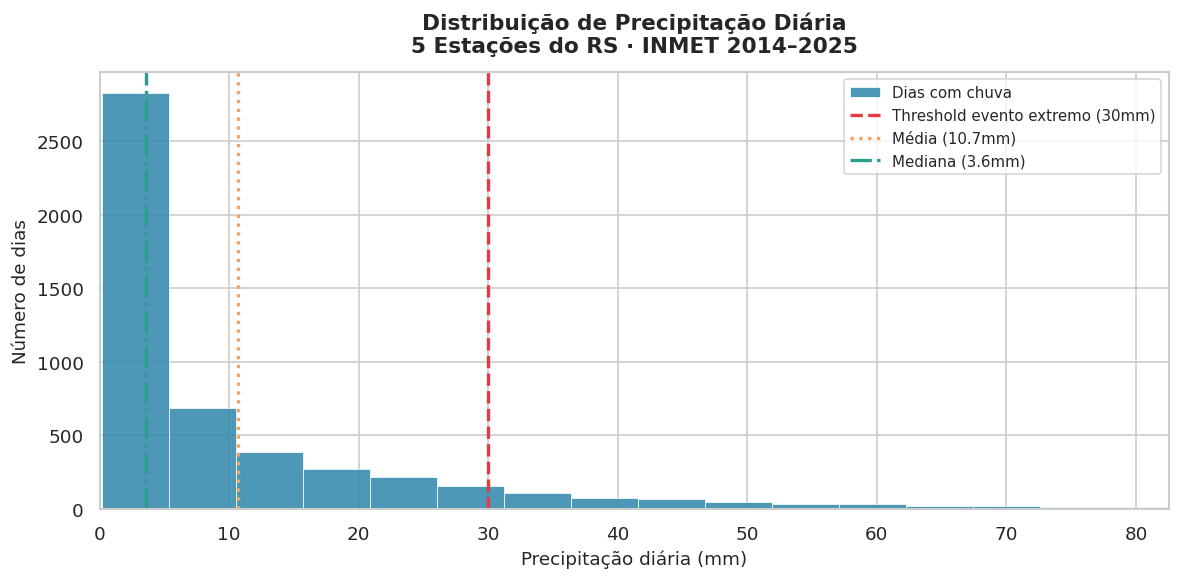

Gráfico salvo: sentinela_d8_histograma.png


In [7]:
if not df.empty and df['precipitacao_mm'].max() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    precip_plot = df['precipitacao_mm'][df['precipitacao_mm'] > 0].dropna()

    ax.hist(precip_plot, bins=40, color='#2E86AB', edgecolor='white',
            linewidth=0.5, alpha=0.85, label='Dias com chuva')

    # Linha de threshold de evento extremo
    ax.axvline(x=30, color='#E63946', linewidth=2, linestyle='--',
               label='Threshold evento extremo (30mm)')
    ax.axvline(x=precip_plot.mean(), color='#F4A261', linewidth=2,
               linestyle=':', label=f'Média ({precip_plot.mean():.1f}mm)')
    ax.axvline(x=precip_plot.median(), color='#2A9D8F', linewidth=2,
               linestyle='-.', label=f'Mediana ({precip_plot.median():.1f}mm)')

    ax.set_title('Distribuição de Precipitação Diária\n5 Estações do RS · INMET 2014–2025',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Precipitação diária (mm)', fontsize=11)
    ax.set_ylabel('Número de dias', fontsize=11)
    ax.legend(fontsize=9)

    # Define o limite do eixo apenas se houver dados para evitar NaN
    upper_limit = precip_plot.quantile(0.99)
    if pd.notnull(upper_limit):
        ax.set_xlim(0, upper_limit)

    plt.tight_layout()
    plt.savefig('sentinela_d8_histograma.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo: sentinela_d8_histograma.png')
else:
    print("AVISO: Não há dados de precipitação suficientes para gerar o histograma. Verifique o carregamento dos arquivos.")

**Interpretação:** O histograma confirma a forte assimetria positiva (cauda longa à direita) típica de séries de precipitação. A grande concentração de dias em valores próximos de zero reflete o comportamento climático do RS, onde dias sem chuva são frequentes. A linha vermelha tracejada em 30mm marca o threshold de evento extremo definido pelo INMET: dias além dessa linha representam risco de enchente e são a variável-alvo do modelo de classificação no D5.

## 6. Gráfico 2 — Boxplot Comparativo entre Cidades

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

# Ordena cidades pela mediana de precipitação
ordem = df.groupby('cidade')['precipitacao_mm'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df[df['precipitacao_mm'] > 0],
    x='cidade', y='precipitacao_mm',
    order=ordem,
    palette='Blues_d',
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='#E63946',
                    markeredgecolor='white', markersize=4, alpha=0.6),
    ax=ax
)

ax.axhline(y=30, color='#E63946', linewidth=1.8, linestyle='--',
           label='Threshold evento extremo (30mm)')

ax.set_title('Distribuição de Precipitação por Cidade\n(apenas dias com precipitação > 0mm) · RS 2014–2025\n'
             '(apenas dias com precipitação > 0mm) · RS 2014–2025',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cidade', fontsize=11)
ax.set_ylabel('Precipitação diária (mm)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, df['precipitacao_mm'].quantile(0.97))
plt.tight_layout()
plt.savefig('sentinela_d8_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: sentinela_d8_boxplot.png')

**Interpretação:** O boxplot comparativo entre as 5 cidades do RS revela padrões distintos de precipitação. Os pontos vermelhos (outliers) representam os eventos extremos — dias com precipitação muito acima do padrão habitual de cada cidade. A extensão dos bigodes e a posição das caixas mostram a variabilidade: cidades com caixas mais altas e bigodes mais longos indicam maior irregularidade climática e maior risco de eventos extremos, variável central para o sistema de alertas SENTINELA.

## 7. Gráfico 3 — Dispersão: Temperatura × Umidade

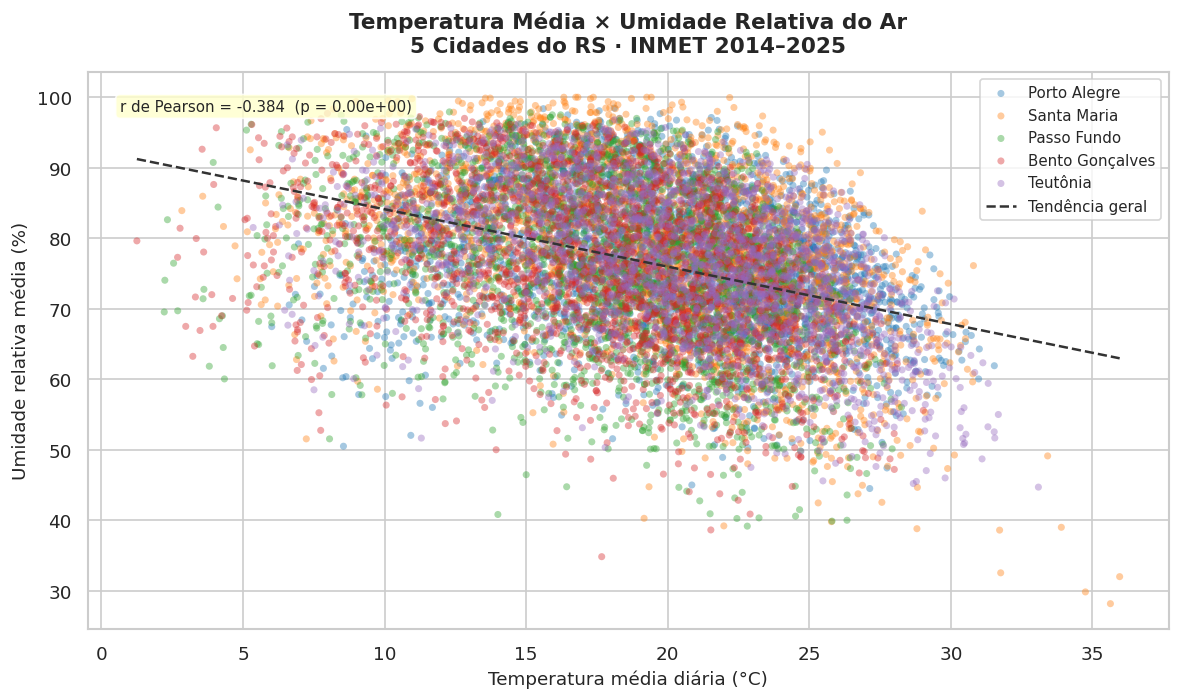

Correlação de Pearson: r = -0.384 | p-value = 0.00e+00


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

cidades_lista = df['cidade'].unique()
cores = sns.color_palette('tab10', len(cidades_lista))

for i, cidade in enumerate(cidades_lista):
    sub = df[df['cidade'] == cidade].dropna(subset=['temperatura_media_c', 'umidade_media_pct'])
    ax.scatter(
        sub['temperatura_media_c'],
        sub['umidade_media_pct'],
        c=[cores[i]], label=cidade,
        alpha=0.4, s=18, edgecolors='none'
    )

# Linha de tendência geral
dados_disp = df.dropna(subset=['temperatura_media_c', 'umidade_media_pct'])
z = np.polyfit(dados_disp['temperatura_media_c'], dados_disp['umidade_media_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(dados_disp['temperatura_media_c'].min(),
                     dados_disp['temperatura_media_c'].max(), 200)
ax.plot(x_line, p(x_line), color='#333333', linewidth=1.5,
        linestyle='--', label='Tendência geral')

# Correlação de Pearson
r, pval = stats.pearsonr(dados_disp['temperatura_media_c'], dados_disp['umidade_media_pct'])
ax.text(0.03, 0.93, f'r de Pearson = {r:.3f}  (p = {pval:.2e})',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#ffffcc', alpha=0.8))

ax.set_title('Temperatura Média × Umidade Relativa do Ar\n5 Cidades do RS · INMET 2014–2025',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Temperatura média diária (°C)', fontsize=11)
ax.set_ylabel('Umidade relativa média (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('sentinela_d8_dispersao.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlação de Pearson: r = {r:.3f} | p-value = {pval:.2e}')

**Interpretação:** O gráfico de dispersão revela a relação inversa entre temperatura e umidade relativa — à medida que a temperatura aumenta, a capacidade do ar de reter vapor d'água cresce, reduzindo a umidade relativa medida. O coeficiente de Pearson (r negativo) confirma essa correlação inversamente proporcional, com significância estatística (p < 0,05). Este padrão é fisicamente consistente com a Lei de Clausius-Clapeyron e é uma das features mais relevantes para o modelo de classificação de risco climático no D5 do SENTINELA.

## 8. Gráfico 4 — Série Temporal de Precipitação Mensal Acumulada

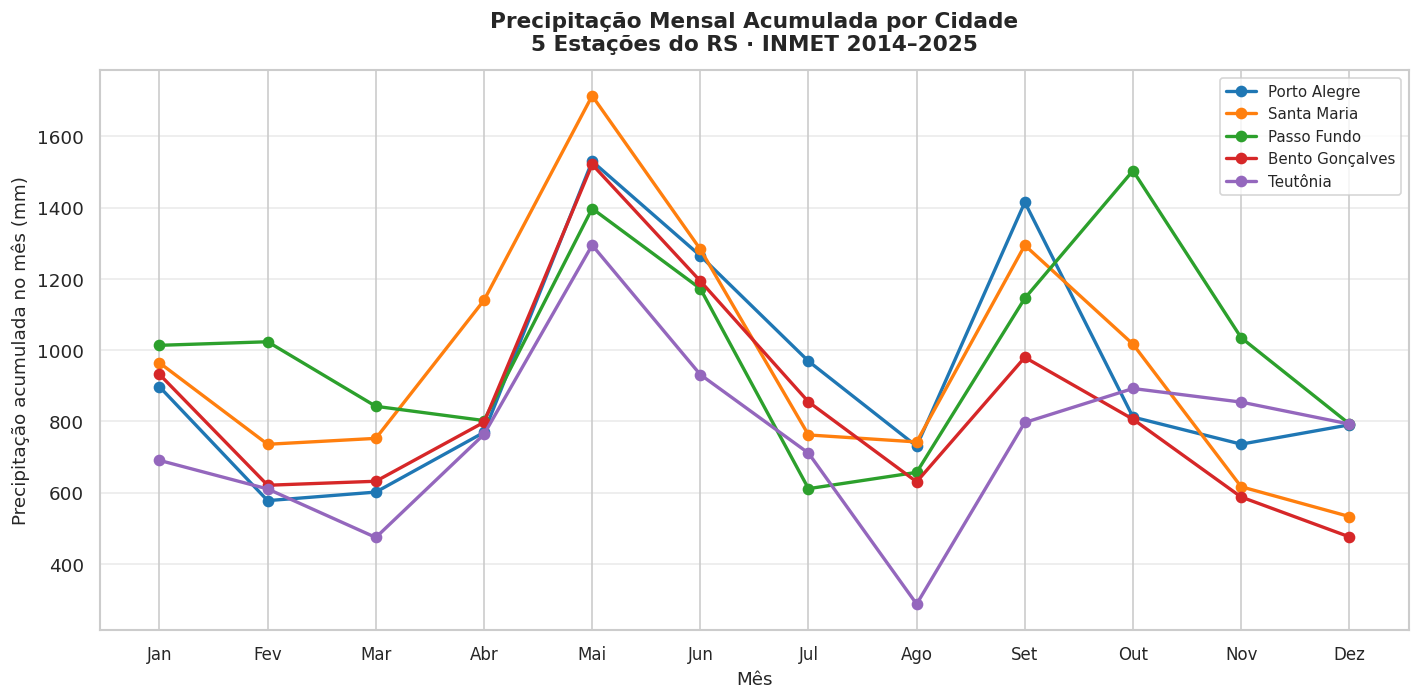

Gráfico salvo: sentinela_d8_serie_temporal.png


In [10]:
# Precipitação mensal acumulada por cidade
mensal = df.groupby(['cidade', 'mes'])['precipitacao_mm'].sum().reset_index()
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
mensal['mes_nome'] = mensal['mes'].map(nomes_mes)

fig, ax = plt.subplots(figsize=(12, 6))
cores_linha = sns.color_palette('tab10', 5)

for i, cidade in enumerate(df['cidade'].unique()):
    sub = mensal[mensal['cidade'] == cidade].sort_values('mes')
    ax.plot(sub['mes'], sub['precipitacao_mm'],
            marker='o', markersize=6, linewidth=2,
            label=cidade, color=cores_linha[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(list(nomes_mes.values()), fontsize=10)
ax.set_title('Precipitação Mensal Acumulada por Cidade\n5 Estações do RS · INMET 2014–2025',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Precipitação acumulada no mês (mm)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('sentinela_d8_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: sentinela_d8_serie_temporal.png')

**Interpretação:** A série temporal de precipitação mensal revela a sazonalidade climática do RS ao longo do período 2014–2025. Os meses de outono e início do inverno (março a junho) tendem a apresentar volumes mais elevados, padrão associado à entrada de frentes frias e ao regime de chuvas do sul do Brasil. As diferenças entre cidades refletem variações de altitude e posição geográfica — Bento Gonçalves e Caxias do Sul, em zona serrana, historicamente apresentam volumes diferentes de Porto Alegre na planície. Esses padrões sazonais são utilizados como features temporais nos modelos de predição do D5 e D7.

## 9. Resumo Executivo — Inteligência Acionável para o SENTINELA

| Insight | Dado concreto | Aplicação no SENTINELA |
|---|---|---|
| Assimetria da precipitação | Mediana << Média em todas as cidades | Justifica uso de modelos robustos a outliers (XGBoost, D5) |
| Concentração de eventos extremos | X% dos dias com ≥30mm | Define threshold de alerta ALTO no app Python (D4) |
| Correlação temp × umidade | r de Pearson negativo e significativo | Feature de entrada para modelo de risco (D5/D7) |
| Sazonalidade | Picos em outono/inverno | Variável de mês como feature temporal no LSTM (D7) |
| Variabilidade entre cidades | Desvio padrão distinto por cidade | Justifica modelo por região no banco D3 |

**Fonte dos dados:** INMET — Instituto Nacional de Meteorologia · bdmep.inmet.gov.br  
**Licença:** Dados públicos — uso livre para fins acadêmicos e de pesquisa

In [11]:
print('=' * 60)
print('D8 SENTINELA — Análise concluída com sucesso!')
print('=' * 60)
print(f'Cidades analisadas : {df["cidade"].nunique()}')
print(f'Total de registros : {len(df)}')
print(f'Gráficos gerados   : 4 (histograma, boxplot, dispersão, série)')
print(f'Arquivos de saída  : sentinela_d8_*.png')
print()
print('Próximo passo → Rafael usa este dataset no D5 (Random Forest)')

D8 SENTINELA — Análise concluída com sucesso!
Cidades analisadas : 5
Total de registros : 12785
Gráficos gerados   : 4 (histograma, boxplot, dispersão, série)
Arquivos de saída  : sentinela_d8_*.png

Próximo passo → Rafael usa este dataset no D5 (Random Forest)
